In [1]:
pip install -r requirements.txt

  Using cached dynamiqs-0.3.5-py3-none-any.whl
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 38.8 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.4/85.4 MB 49.7 MB/s eta 0:00:00:00:0100:01
  Attempting uninstall: jaxlib
    Found existing installation: jaxlib 0.9.2
    Uninstalling jaxlib-0.9.2:
      Successfully uninstalled jaxlib-0.9.2
  Attempting uninstall: jax
    Found existing installation: jax 0.9.2
    Uninstalling jax-0.9.2:
      Successfully uninstalled jax-0.9.2

[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "2"
from cheb_ar import *
import time

/home/tmalasda/venvs/dq_gpu/lib/python3.11/site-packages/dynamiqs/__init__.py


In [2]:
# ---------------- parameters (same as your snippet) ----------------
w_a = 25.338776456203686
w_b = 2 * w_a
kappa_b = 5 / 10.4
E_J = 37 * 2 * np.pi
phi_a, phi_b = 0.11, 0.204
epsilon_p = 0.1
g  = np.sin(epsilon_p) * E_J * phi_a**2 * phi_b
g2 = jv(1, epsilon_p) * E_J * phi_a**2 * phi_b
kappa_2 = 4 * g**2 / kappa_b
kappa_1 = 0.005 * kappa_2
n_a, n_b = 25, 11
dims = (n_a, n_b)
alpha_sq = 8.5
epsilon_d = 2 * alpha_sq * g2

N = n_a * n_b
T_block = 2 * jnp.pi / w_a
tsave = jnp.array([0.0, T_block])
method = dq.method.Tsit5(rtol=1e-9, atol=1e-10)
opts = dq.Options(assume_hermitian=False)

In [3]:
def build_ats_hamiltonian(
    n_a=20,
    n_b=11,
    alpha_sq=8.5,
    w_a=25.338776456203686,
    kappa_b=5 / 10.4,
    E_J=37 * 2 * np.pi,
    phi_a=0.11,
    phi_b=0.204,
    epsilon_p=0.1,
    n_periods=1,
):
    """Build the driven full-ATS Lindbladian in the rotating frame.

    Mirrors the operator/Hamiltonian cells of ``Chebyshev-Arnoldi.ipynb``.

    Returns
    -------
    Ham : dynamiqs time-dependent operator
        The rotating-frame Hamiltonian ``Ham_full_r``.
    jump_ops : list
        Lindblad jump operators ``[sqrt(kappa_1) a, sqrt(kappa_b) b]``.
    T_block : float
        Duration of one Floquet block, ``n_periods * 2*pi / w_a``.
    params : dict
        Derived quantities (``g``, ``g2``, ``kappa_1``, ``kappa_2``,
        ``epsilon_d``, ``w_b``, ``T_drive``) for reference.
    """
    w_b = 2 * w_a

    # couplings derived from the pump
    g = np.sin(epsilon_p) * E_J * phi_a**2 * phi_b
    g2 = jv(1, epsilon_p) * E_J * phi_a**2 * phi_b

    kappa_2 = 4 * g**2 / kappa_b
    kappa_1 = 0.005 * kappa_2

    epsilon_d = 2 * alpha_sq * g2

    # Operators
    a = dq.destroy(n_a)
    b = dq.destroy(n_b)
    Ia = dq.eye(n_a)
    Ib = dq.eye(n_b)

    a_tot = dq.tensor(a, Ib)
    b_tot = dq.tensor(Ia, b)

    phi_a_tot = phi_a*(a_tot + dq.dag(a_tot))
    phi_b_tot = phi_b*(b_tot + dq.dag(b_tot))

    non_linear_op = dq.sinm(phi_a_tot + phi_b_tot) - phi_a_tot - phi_b_tot

    H_drive = dq.modulated(
        lambda t: epsilon_d * jnp.cos(w_b*t),
        b_tot + dq.dag(b_tot)
        )

    H_0 = w_a*a_tot@dq.dag(a_tot) + w_b*b_tot@dq.dag(b_tot)

    Ham = H_0 + H_drive - 2*E_J*jnp.sin(epsilon_p)*non_linear_op 

    jump_ops = [
        jnp.sqrt(kappa_1) * a_tot,
        jnp.sqrt(kappa_b) * b_tot,
    ]

    T_drive = 2 * jnp.pi / w_a
    T_block = n_periods * T_drive

    params = {
        "g": g,
        "g2": g2,
        "kappa_1": kappa_1,
        "kappa_2": kappa_2,
        "kappa_b": kappa_b,
        "epsilon_d": epsilon_d,
        "w_a": w_a,
        "w_b": w_b,
        "T_drive": T_drive,
    }
    return Ham, jump_ops, T_block, params
Ham, jump_ops, T_block, params = build_ats_hamiltonian()
solver = ChebAr(Ham, jump_ops, T_block, dims=dims)
m_arnoldi_0 = 60
x0 = solver.make_x0(seed=0)
#_, _, ritz_vals = solver.first_estimation(x0, m_arnoldi=m_arnoldi_0)

/home/tmalasda/venvs/dq_gpu/lib/python3.11/site-packages/equinox/_module/_prebuilt.py:46: UserWarning: A `SparseDIADataArray` has been converted to a `DenseDataArray` while computing its matrix exponential.
  return self.__func__(self.__self__, *args, **kwargs)
/home/tmalasda/venvs/dq_gpu/lib/python3.11/site-packages/dynamiqs/qarrays/dataarray.py:214: UserWarning: A sparse data array has been converted to dense layout due to element-wise addition with a dense data array.
  return self.__add__(y)


In [6]:
def build_ats_hamiltonian_interaction(
    n_a=25,
    n_b=11,
    alpha_sq=8.5,
    w_a=25.338776456203686,
    kappa_b=5 / 10.4,
    E_J=37 * 2 * np.pi,
    phi_a=0.11,
    phi_b=0.204,
    epsilon_p=0.1,
    n_periods=1,
):
    """Build the driven full-ATS Lindbladian in the interaction frame.

    Returns
    -------
    H_I : time-dependent dynamiqs operator
        Driving part of the Hamiltonian.
    jump_ops : list
        Time-dependent Lindblad jump operators ``[sqrt(kappa_1) a, sqrt(kappa_b) b]``.
    T_block : float
        Duration of one Floquet block, ``n_periods * 2*pi / w_a``.
    params : dict
        Derived quantities (``g``, ``g2``, ``kappa_1``, ``kappa_2``,
        ``epsilon_d``, ``w_b``, ``T_drive``) for reference.
    """
    w_b = 2 * w_a

    # couplings derived from the pump
    g = np.sin(epsilon_p) * E_J * phi_a**2 * phi_b
    g2 = jv(1, epsilon_p) * E_J * phi_a**2 * phi_b

    kappa_2 = 4 * g**2 / kappa_b
    kappa_1 = 0.005 * kappa_2

    epsilon_d = 2 * alpha_sq * g2

    # Operators
    a = dq.destroy(n_a)
    b = dq.destroy(n_b)
    Ia = dq.eye(n_a)
    Ib = dq.eye(n_b)

    a_tot = dq.tensor(a, Ib)
    b_tot = dq.tensor(Ia, b)

    phi_a_tot = phi_a*(a_tot + dq.dag(a_tot))
    phi_b_tot = phi_b*(b_tot + dq.dag(b_tot))

    non_linear_op = dq.sinm(phi_a_tot + phi_b_tot) - phi_a_tot - phi_b_tot

    H_s = (w_a * dq.dag(a_tot) @ a_tot + w_b * dq.dag(b_tot) @ b_tot
           - 2 * E_J * jnp.sin(epsilon_p) * non_linear_op)

    Hs_mat = H_s.to_numpy()
    Hs_mat = 0.5 * (Hs_mat + Hs_mat.conj().T)          # symmetrize numerically
    lam, V = np.linalg.eigh(Hs_mat)                    # H_s = V diag(lam) V^dag
    Vd = V.conj().T

    a_bar = jnp.array(Vd @ a_tot.to_numpy() @ V)        # fixed, built once
    b_bar = jnp.array(Vd @ b_tot.to_numpy() @ V)
    Delta = jnp.array(lam[:, None] - lam[None, :])      # fixed, built once

    def a_tilde_fn(t):
        return dq.asqarray(a_bar * jnp.exp(1j*Delta*t), dims=(n_a, n_b))

    def b_tilde_fn(t):
        return dq.asqarray(b_bar * jnp.exp(1j*Delta*t), dims=(n_a, n_b))

    a_tilde = dq.timecallable(a_tilde_fn)
    b_tilde = dq.timecallable(b_tilde_fn)

    def H_drive_I_fn(t):
        bt = b_tilde_fn(t)
        return epsilon_d * jnp.cos(w_b * t) * (bt + dq.dag(bt))

    H_I = dq.timecallable(H_drive_I_fn)
    jump_ops_I = [jnp.sqrt(kappa_1) * a_tilde, jnp.sqrt(kappa_b) * b_tilde]


    a_dag_a_bar = a_bar.conj().T @ a_bar
    b_dag_b_bar = b_bar.conj().T @ b_bar

    def a_dag_a_tilde_fn(t):
        return dq.asqarray(a_dag_a_bar * jnp.exp(1j * Delta * t), dims=(n_a, n_b))

    def b_dag_b_tilde_fn(t):
        return dq.asqarray(b_dag_b_bar * jnp.exp(1j * Delta * t), dims=(n_a, n_b))

    a_dag_a_tilde = dq.timecallable(a_dag_a_tilde_fn)
    b_dag_b_tilde = dq.timecallable(b_dag_b_tilde_fn)

    jump_ops_LdL_I = [kappa_1 * a_dag_a_tilde, kappa_b * b_dag_b_tilde]

    T_drive = 2 * jnp.pi / w_a
    T_block = n_periods * T_drive

    
    output_phase = jnp.exp(-1j * jnp.array(lam) * T_block)   # the missing piece

    params = {
        "g": g,
        "g2": g2,
        "kappa_1": kappa_1,
        "kappa_2": kappa_2,
        "kappa_b": kappa_b,
        "epsilon_d": epsilon_d,
        "w_a": w_a,
        "w_b": w_b,
        "T_drive": T_drive,
    }
    return H_I, jump_ops_I, jump_ops_LdL_I, output_phase, V, T_block, params

In [7]:
H_I, jump_ops_I, jump_ops_LdL_I, output_phase, V, T_block, params = build_ats_hamiltonian_interaction()
solver = ChebAr(H_I, jump_ops_I, T_block, jump_ops_LdL=jump_ops_LdL_I, dims=dims, output_phase=output_phase)
_, _, ritz_vals = solver.first_estimation(x0, m_arnoldi=m_arnoldi_0)

/home/tmalasda/venvs/dq_gpu/lib/python3.11/site-packages/equinox/_module/_prebuilt.py:46: UserWarning: A `SparseDIADataArray` has been converted to a `DenseDataArray` while computing its matrix exponential.
  return self.__func__(self.__self__, *args, **kwargs)
/home/tmalasda/venvs/dq_gpu/lib/python3.11/site-packages/dynamiqs/qarrays/dataarray.py:214: UserWarning: A sparse data array has been converted to dense layout due to element-wise addition with a dense data array.
  return self.__add__(y)
/home/tmalasda/venvs/dq_gpu/lib/python3.11/site-packages/dynamiqs/qarrays/qarray.py:534: UserWarning: A sparse data array has been converted to dense layout due to element-wise addition with a dense data array.
  result = self.data + y.data
|██████████| 100.0% ◆ elapsed 76.62ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 71.74ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 71.75ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 59.08ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 

In [8]:
margin = 1e-2
solver.setup_chebyshev(ritz_vals, margin=margin)
warm_start = False

/home/tmalasda/dev/cheb_ar_repo/cheb_ar.py:454: ComplexWarning: Casting complex values to real discards the imaginary part
  max_level = float(np.max(levels))


In [9]:
m_arnoldi = 120
Q, H, mu_list = solver.arnoldi_hessenberg(x0, solver.chebyshev_filter, m_arnoldi, warm_start = warm_start)

|██████████| 100.0% ◆ elapsed 74.33ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 90.76ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 115.89ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 133.14ms ◆ remaining 0.00ms 
|██████████| 100.0% ◆ elapsed 147.41ms ◆ remaining 0.00ms 
|██████████| 100.0% ◆ elapsed 164.38ms ◆ remaining 0.00ms 
|██████████| 100.0% ◆ elapsed 54.83ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 83.56ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 118.73ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 152.39ms ◆ remaining 0.00ms 
|██████████| 100.0% ◆ elapsed 188.73ms ◆ remaining 0.00ms 
|██████████| 100.0% ◆ elapsed 208.48ms ◆ remaining 0.00ms 
|██████████| 100.0% ◆ elapsed 56.90ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 82.74ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 118.40ms ◆ remaining 0.00ms
|██████████| 100.0% ◆ elapsed 161.65ms ◆ remaining 0.00ms 
|██████████| 100.0% ◆ elapsed 207.25ms ◆ remaining 0.00ms 
|██████████|

In [10]:
rate_bf = solver.rate_from_mu(mu_list[-1])
x_ritz, _ = solver.ritz_vector(Q, H, m_arnoldi)
res = solver.residual_check(x_ritz)

|██████████| 100.0% ◆ elapsed 58.94ms ◆ remaining 0.00ms


In [11]:
rate_bf

Array(3.99930635e-07-2.881719e-16j, dtype=complex128)

In [12]:
rho_lab   = V @ x_ritz.reshape(N, N) @ V.conj().T

In [13]:
rho_lab_dq = dq.asqarray(rho_lab, dims=dims)

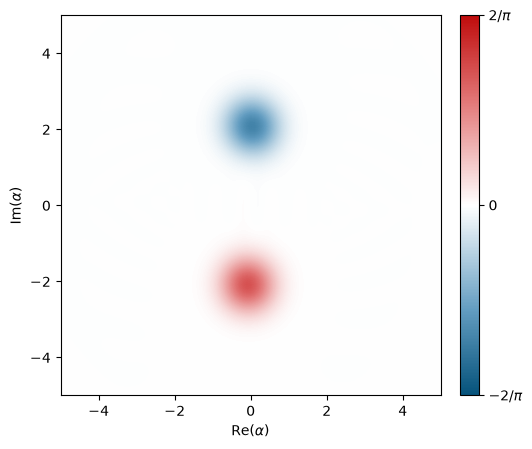

In [14]:
dq.plot.wigner(dq.ptrace(rho_lab_dq,0))